# Análisis exploratorio: llegadas internacionales a Costa Rica


En este notebook se exploran los datos generados en `01_limpieza.ipynb` para analizar las llegadas internacionales de turistas a Costa Rica entre 2017 y 2025.

- **Datos:** `data/processed/llegadas_por_pais.csv`
- **Contenido:** llegadas por año, país y región de origen.

**Preguntas de análisis:**

1. **Evolución:** ¿cómo han cambiado las llegadas internacionales entre 2017 y 2025? ¿Cuánto cayeron durante la pandemia y en qué año se recuperó el nivel de 2019?
2. **Mercados de origen:** ¿qué países y regiones aportan más turistas? ¿Todos los mercados se recuperaron de la misma forma después de la pandemia?
3. **Puertas de entrada:** ¿qué proporción de turistas llega por vía aérea frente a la vía terrestre y marítima? ¿Varía según la región de origen?

## 1. Carga de datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/processed/llegadas_por_pais.csv', dtype={'llegadas': 'Int64'})
df.head()

,region,pais,anio,llegadas
0,AMÉRICA DEL NORTE,Canadá,2017,201921
1,AMÉRICA DEL NORTE,Estados Unidos,2017,1199241
2,AMÉRICA DEL NORTE,México,2017,106783
3,AMÉRICA CENTRAL,Belice,2017,970
4,AMÉRICA CENTRAL,El Salvador,2017,81091


## 2. Evolución de las llegadas

In [3]:
por_anio = df.groupby('anio')['llegadas'].sum()
por_anio

anio
2017    2959869
2018    3016667
2019    3139008
2020    1011912
2021    1347055
2022    2349537
2023    2751134
2024    2919483
2025    2943991
Name: llegadas, dtype: Int64

In [4]:
variacion = (por_anio.pct_change() * 100).round(1)
variacion

anio
2017    <NA>
2018     1.9
2019     4.1
2020   -67.8
2021    33.1
2022    74.4
2023    17.1
2024     6.1
2025     0.8
Name: llegadas, dtype: Float64

In [5]:
vs_2019 = (por_anio / por_anio[2019] * 100).round(1)
vs_2019

anio
2017     94.3
2018     96.1
2019    100.0
2020     32.2
2021     42.9
2022     74.8
2023     87.6
2024     93.0
2025     93.8
Name: llegadas, dtype: Float64

### Hallazgos

- **Caída:** la pandemia afectó fuertemente la llegada de turistas al país. En 2020 llegaron 67,8 % menos turistas que en 2019.
- **Recuperación:** en 2021 y 2022 la recuperación fue rápida, pero luego se fue frenando: +17,1 % en 2023, +6,1 % en 2024 y apenas +0,8 % en 2025.
- **A destacar:** seis años después del inicio de la pandemia, en 2025 Costa Rica todavía está en el 93,8 % del nivel de 2019. Las llegadas no se han recuperado del todo.

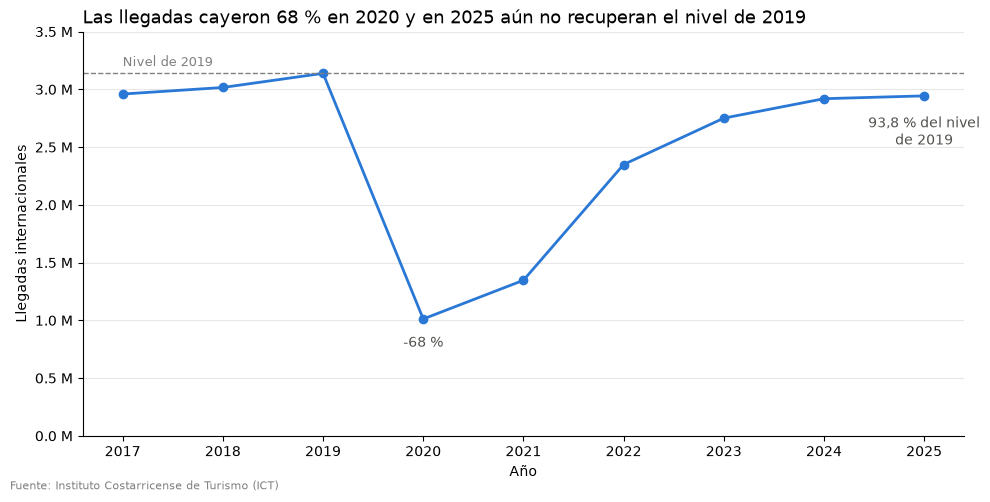

In [13]:
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(10, 5))

# 1. Línea principal
ax.plot(por_anio.index, por_anio.values, color='#2a78d6', linewidth=2, marker='o')

# 2. Línea de referencia: nivel de 2019
ax.axhline(y=por_anio[2019], color='gray', linestyle='--', linewidth=1)
ax.text(2017, por_anio[2019] * 1.02, 'Nivel de 2019', color='gray', fontsize=9)

# 3. Etiquetas en los puntos clave
ax.annotate('-68 %', xy=(2020, por_anio[2020]), xytext=(0, -20),
            textcoords='offset points', ha='center', color='#52514e')
ax.annotate('93,8 % del nivel\nde 2019', xy=(2025, por_anio[2025]), xytext=(0, -35),
            textcoords='offset points', ha='center', color='#52514e')

# 4. Títulos y etiquetas de los ejes
ax.set_title('Las llegadas cayeron 68 % en 2020 y en 2025 aún no recuperan el nivel de 2019',
             loc='left', fontsize=13)
ax.set_xlabel('Año')
ax.set_ylabel('Llegadas internacionales')

# 5. Ejes: todos los años, eje Y desde cero y en millones
ax.set_xticks(por_anio.index)
ax.set_ylim(0, 3.5e6)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:.1f} M'))

# 6. Estilo: cuadrícula suave y sin bordes arriba ni a la derecha
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

# 7. Fuente de los datos
fig.text(0.01, 0.01, 'Fuente: Instituto Costarricense de Turismo (ICT)', fontsize=8, color='gray')

# 8. Guardar y mostrar
plt.tight_layout()
plt.savefig('../figures/01_evolucion_llegadas.png', dpi=150, bbox_inches='tight')
plt.show()

**Gráfico 1:** llegadas internacionales por año, comparadas con el nivel de 2019.